In [ ]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns

#loading data
dataset=load_dataset('lukebarousse/data_jobs')

#converting the loaded dataset into a pandas dataframe
df=dataset['train'].to_pandas()

#formatting datetime
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

#cleaning the job_skills column by converting them from strings into lists
import ast
df['job_skills']=df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills )


In [11]:
#Filtering out jobs in the US and removing NaN values from the yearly salary column
df_us=df[df['job_country']=='United States']
df_us=df_us.dropna(subset='salary_year_avg')

In [22]:
#obtaining the top 6 most listed jobs
top6=df_us['job_title_short'].value_counts().head(6).index.to_list()
df_top6=df_us[df_us['job_title_short'].isin (top6)]

In [32]:
#Grouping by job title and median salary and sorting them in descending order based on median salary
job_order=df_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

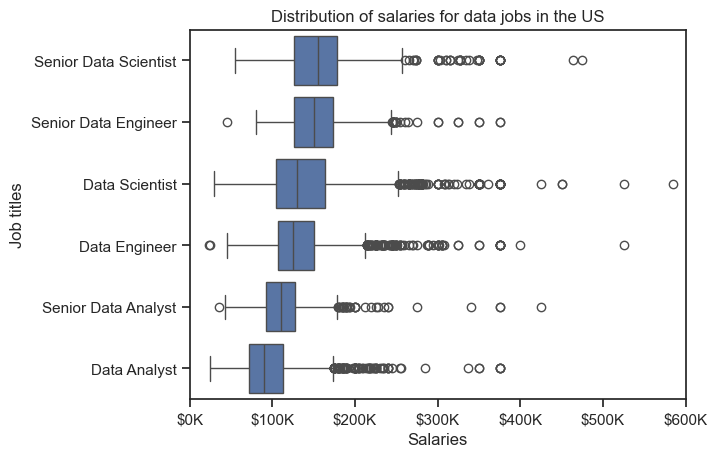

In [35]:
#creating a box plot that shows the distribution of salaries for the 6 jobs in the US
sns.boxplot(df_top6,x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.title('Distribution of salaries for data jobs in the US')
plt.xlim(0,600000)
plt.xlabel('Salaries')
plt.ylabel('Job titles')
plt.show()

In [50]:
#analysing highly paid skills vs salaries associated with the most demanded skills
#filtering data analyst jobs in the US, removing NA values from yearly salaries, and exploding skills column
df_da=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')]
df_da=df_da.dropna(subset='salary_year_avg')
df_da=df_da.explode('job_skills')

In [52]:
#grouping by skill count and median salary
df_grouped=df_da.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

In [57]:
#creating 2 dataframes - one of them for highest paid skills and the other for skills in demand
df_salary=df_grouped.sort_values(by='median', ascending=False).head(10)
df_skills=df_grouped.sort_values(by='count',ascending=False).head(10).sort_values(by='median', ascending=False)

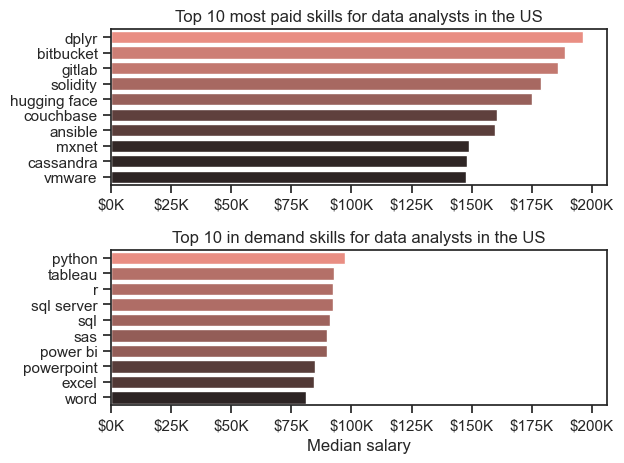

In [63]:
#plotting a bar graph that compares these 2 dataframes
fig,ax=plt.subplots(2,1)
sns.set_theme(style='ticks')
sns.barplot(df_salary, y=df_salary.index, x='median', ax=ax[0], hue='median', palette='dark:salmon')
ax[0].legend().remove()
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_title('Top 10 most paid skills for data analysts in the US')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
sns.barplot(df_skills, x='median', y=df_skills.index, ax=ax[1], hue='median', palette='dark:salmon')
ax[1].legend().remove()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_ylabel('')
ax[1].set_xlabel('Median salary')
ax[1].set_title('Top 10 in demand skills for data analysts in the US')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.tight_layout()